# Star Rating Prediction from Review Text

This notebook focuses on predicting exact star ratings (1–5) from review text.
The task is challenging because adjacent ratings often reflect subtle differences in sentiment.

The workflow is structured as follows:
1. Data preparation and train/test split
2. Baseline models implementation and evaluation
3. Comparison of all models


## Data Preparation

In [1]:
pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.1 MB/s eta 0:00:00


### Imports

In [2]:
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from gensim.models import Word2Vec

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

from datasets import Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)


### Loading the cleaned dataset

The cleaned dataset is loaded and only the relevant columns are kept:
- `note`: target variable (rating)
- `type`: train/test split indicator
- text representations for modeling

The dataset is then split into:
- a labelled training set
- an unlabelled test set

In [3]:
df = pd.read_csv("dataset_cleaned.csv")

useful_columns = ["note", "type", "avis_en_tfidf_lda", "avis_en_embeddings"]
df_model = df[useful_columns].copy()
df_model["type"] = df_model["type"].astype(str).str.lower().str.strip()
df_model["avis_en_tfidf_lda"] = df_model["avis_en_tfidf_lda"].fillna("").astype(str)
df_model["avis_en_embeddings"] = df_model["avis_en_embeddings"].fillna("").astype(str)

train_df = df_model[(df_model["type"] == "train") & (df_model["note"].notna())].copy()
test_df = df_model[df_model["type"] == "test"].copy()
train_df["note"] = train_df["note"].astype(int)


### Data overview

Before training, a quick check is performed to:
- verify dataset sizes
- inspect class distribution
- observe review length distribution

This helps identify potential issues such as class imbalance or extreme text lengths.

Full dataset shape: (6000, 16)
Labelled train rows: (5000, 4)
Unlabelled official test rows: (1000, 4)
Rating distribution in train:
note
1    1546
2     787
3     693
4    1000
5     974
Name: count, dtype: int64


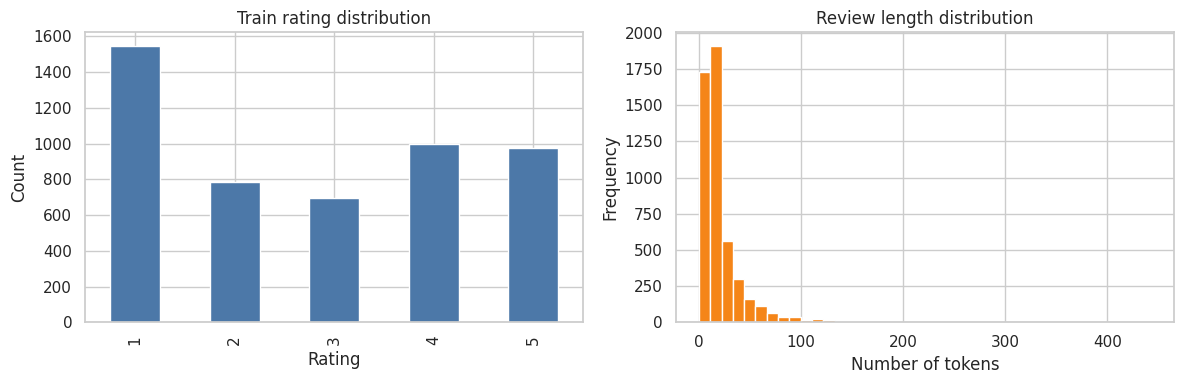

In [4]:
print("Full dataset shape:", df.shape)
print("Labelled train rows:", train_df.shape)
print("Unlabelled official test rows:", test_df.shape)
print("Rating distribution in train:")
print(train_df["note"].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df["note"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4c78a8")
axes[0].set_title("Train rating distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

train_df["avis_en_tfidf_lda"].str.split().map(len).plot(kind="hist", bins=40, ax=axes[1], color="#f58518")
axes[1].set_title("Review length distribution")
axes[1].set_xlabel("Number of tokens")

plt.tight_layout()
plt.show()


A stratified validation split is created to ensure that both the training and validation sets preserve the original rating distribution. This is particularly important given the imbalance observed in the dataset. The distributions printed above confirm that each rating class is represented in similar proportions across the two splits, which ensures that the evaluation will be reliable and comparable across models.

Looking at the rating distribution, we observe a clear imbalance with a strong dominance of rating 1, followed by ratings 4 and 5, while ratings 2 and 3 remain less frequent. This confirms that the model will have more examples to learn extreme opinions than intermediate ones. As a result, predicting middle ratings is likely to be more difficult, especially since they often correspond to more nuanced or ambiguous reviews.

The review length distribution highlights another important characteristic: most reviews are short, with a high concentration below 50 tokens, and only a small number of longer reviews extending beyond 100 tokens. This means that the majority of inputs contain limited textual information, which can restrict the model’s ability to capture subtle sentiment differences. While longer reviews may provide richer context, they are too rare to significantly influence the overall learning process.

### Validation strategy

To ensure a fair and consistent evaluation across all models, a single validation split is created and reused throughout the notebook. A stratified split is applied so that the distribution of ratings remains consistent between the training and validation sets.

In [5]:
# Purpose: Creating one shared validation split.
# The intermediate output from this cell is kept intentionally for transparency and validation.
X_tfidf = train_df["avis_en_tfidf_lda"].copy()
X_embed = train_df["avis_en_embeddings"].copy()
y = train_df["note"].copy()

train_idx, valid_idx = train_test_split(
    train_df.index,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

X_train_tfidf = X_tfidf.loc[train_idx]
X_valid_tfidf = X_tfidf.loc[valid_idx]
X_train_embed = X_embed.loc[train_idx]
X_valid_embed = X_embed.loc[valid_idx]
y_train = y.loc[train_idx]
y_valid = y.loc[valid_idx]

print(X_train_tfidf.shape, X_valid_tfidf.shape)
print("Train distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("Validation distribution:")
print(y_valid.value_counts(normalize=True).sort_index().round(3))


(4000,) (1000,)
Train distribution:
note
1    0.309
2    0.158
3    0.138
4    0.200
5    0.195
Name: proportion, dtype: float64
Validation distribution:
note
1    0.309
2    0.157
3    0.139
4    0.200
5    0.195
Name: proportion, dtype: float64


The distributions in the training and validation sets are almost identical, confirming that stratification is correctly applied. All rating classes are preserved with similar proportions, including the less frequent ones.

This ensures that the validation set is representative and that model evaluation remains reliable despite the class imbalance.

In [6]:
# Validate the shared train-validation split used by every model.
print('Training rows:', len(train_idx))
print('Validation rows:', len(valid_idx))
print('Overlap between indices:', len(set(train_idx).intersection(set(valid_idx))))
print('Training label distribution:')
print(y_train.value_counts().sort_index())
print('Validation label distribution:')
print(y_valid.value_counts().sort_index())
assert set(train_idx).isdisjoint(set(valid_idx)), 'Train and validation sets must be disjoint.'


Training rows: 4000
Validation rows: 1000
Overlap between indices: 0
Training label distribution:
note
1    1237
2     630
3     554
4     800
5     779
Name: count, dtype: int64
Validation label distribution:
note
1    309
2    157
3    139
4    200
5    195
Name: count, dtype: int64


The training and validation sets are verified to ensure they are disjoint and correctly balanced. This confirms that the split is valid and that no data leakage occurs between training and evaluation.

### Evaluation framework

Evaluation metrics and reporting functions are centralized to ensure consistency across all models. This avoids discrepancies in scoring and simplifies the final comparison.

In [7]:
RATING_ORDER = [1, 2, 3, 4, 5]
results_regression = []
results_classification = []


def evaluate_regression(model_name, y_true, y_pred):
    metrics = {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }
    result = pd.DataFrame([metrics])
    results_regression.append(result)
    return result



def evaluate_classification(model_name, y_true, y_pred):
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro_F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted_F1": f1_score(y_true, y_pred, average="weighted"),
    }
    result = pd.DataFrame([metrics])
    results_classification.append(result)
    cm = confusion_matrix(y_true, y_pred, labels=RATING_ORDER)
    return result, cm



def show_report(y_true, y_pred):
    print(classification_report(y_true, y_pred, labels=RATING_ORDER, zero_division=0))



def show_confusion_matrix(y_true, y_pred, title):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_true, y_pred, labels=RATING_ORDER),
        display_labels=RATING_ORDER,
    )
    disp.plot(cmap="Blues", values_format="d")
    plt.title(title)
    plt.show()

## Baseline models implementation and evaluation

### Simple baselines

Two simple baselines are used as reference points: a mean regressor and a majority class classifier. These models do not use text information and provide a minimum performance level that more complex models should exceed.

In [8]:
mean_baseline = DummyRegressor(strategy="mean")
mean_baseline.fit(np.zeros((len(y_train), 1)), y_train)
y_pred_mean = mean_baseline.predict(np.zeros((len(y_valid), 1)))
results_mean_reg = evaluate_regression("Baseline Mean Regressor", y_valid, y_pred_mean)

majority_baseline = DummyClassifier(strategy="most_frequent")
majority_baseline.fit(np.zeros((len(y_train), 1)), y_train)
y_pred_majority = majority_baseline.predict(np.zeros((len(y_valid), 1)))
results_majority, cm_majority = evaluate_classification("Baseline Majority Class", y_valid, y_pred_majority)

results_mean_reg, results_majority

(                     Model       MAE      RMSE            R2
 0  Baseline Mean Regressor  1.377682  1.529306 -9.620421e-07,
                      Model  Accuracy  Macro_F1  Weighted_F1
 0  Baseline Majority Class     0.309  0.094423     0.145884)

The mean regressor achieves an MAE of 1.38 and an R² close to 0, indicating that it does not capture any meaningful relationship between input and target. It simply predicts the average rating for all samples.

The majority class classifier reaches an accuracy of 31.75%, which corresponds to always predicting the most frequent class (rating 1). However, the very low macro F1 score (0.096) shows that it performs poorly on all other classes.

These results highlight that naive approaches fail to model the task properly. They also provide a useful baseline: any meaningful model should significantly outperform these scores.

### TF-IDF + Ridge regressor

In [9]:
ridge_tfidf = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=20000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
            ),
        ),
        ("reg", Ridge(alpha=1.0)),
    ]
)

ridge_tfidf.fit(X_train_tfidf, y_train)
y_pred_ridge_tfidf = ridge_tfidf.predict(X_valid_tfidf)
results_ridge_tfidf = evaluate_regression("TF-IDF + Ridge", y_valid, y_pred_ridge_tfidf)
results_ridge_tfidf


,Model,MAE,RMSE,R2
0,TF-IDF + Ridge,0.73444,0.904554,0.650151


The model significantly improves over the naive baseline, with an MAE of 0.80 and an R² of 0.59. This indicates that it captures a meaningful relationship between review text and ratings.

The relatively low error shows that the model is able to estimate the overall sentiment of a review. However, as a regression approach, it may struggle to predict exact discrete ratings, especially between adjacent classes such as 3, 4, and 5.

Overall, this model provides a strong baseline and confirms that TF-IDF features are effective for this task.

### TF-IDF + Logistic Regression

In [10]:
logreg_tfidf = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=20000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
            ),
        ),
        (
            "clf",
            LogisticRegression(
                max_iter=4000,
                class_weight="balanced",
                random_state=SEED,
            ),
        ),
    ]
)

logreg_tfidf.fit(X_train_tfidf, y_train)
y_pred_logreg_tfidf = logreg_tfidf.predict(X_valid_tfidf)
results_logreg_tfidf, cm_logreg_tfidf = evaluate_classification(
    "TF-IDF + Logistic Regression", y_valid, y_pred_logreg_tfidf
)
results_logreg_tfidf


,Model,Accuracy,Macro_F1,Weighted_F1
0,TF-IDF + Logistic Regression,0.477,0.419413,0.463313


              precision    recall  f1-score   support

           1       0.63      0.70      0.66       309
           2       0.30      0.32      0.31       157
           3       0.25      0.16      0.19       139
           4       0.42      0.33      0.37       200
           5       0.51      0.63      0.56       195

    accuracy                           0.48      1000
   macro avg       0.42      0.43      0.42      1000
weighted avg       0.46      0.48      0.46      1000



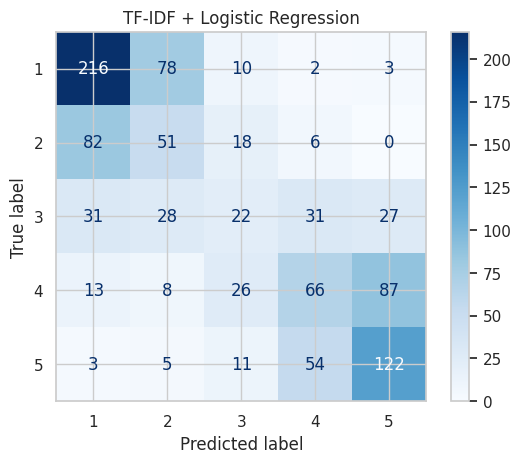

In [11]:
show_report(y_valid, y_pred_logreg_tfidf)
show_confusion_matrix(y_valid, y_pred_logreg_tfidf, "TF-IDF + Logistic Regression")

The model achieves an accuracy of 0.47 and a macro F1 score of 0.41, showing a clear improvement over the baseline. Using TF-IDF with a classification approach allows the model to better predict discrete rating classes.

Performance varies across classes. Rating 1 is relatively well predicted with 84 correct predictions out of 127, while rating 5 also shows solid performance with 38 correct predictions. Rating 4 is moderately well captured with 37 correct predictions, but still suffers from confusion with rating 5 (24 misclassified as 5).

In contrast, intermediate ratings are much harder to predict. Rating 2 has only 22 correct predictions out of 63, with many misclassified as rating 1 (33 cases). Rating 3 is the most problematic, with only 6 correct predictions out of 52, and frequent confusion with both lower ratings (16 predicted as 1) and higher ratings (11 predicted as 4 and 11 as 5).

The confusion matrix clearly shows that most errors occur between neighboring classes, especially between 4 and 5, and between 1 and 2. Overall, the model captures general sentiment but struggles with fine-grained distinctions, particularly for neutral or ambiguous reviews.

### TF-IDF + Linear SVM

In [12]:
svm_tfidf = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=20000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
            ),
        ),
        ("clf", LinearSVC(class_weight="balanced", random_state=SEED)),
    ]
)

svm_tfidf.fit(X_train_tfidf, y_train)
y_pred_svm_tfidf = svm_tfidf.predict(X_valid_tfidf)
results_svm_tfidf, cm_svm_tfidf = evaluate_classification(
    "TF-IDF + Linear SVM", y_valid, y_pred_svm_tfidf
)
results_svm_tfidf


,Model,Accuracy,Macro_F1,Weighted_F1
0,TF-IDF + Linear SVM,0.475,0.410479,0.455688


              precision    recall  f1-score   support

           1       0.61      0.72      0.66       309
           2       0.34      0.29      0.32       157
           3       0.22      0.14      0.17       139
           4       0.38      0.32      0.35       200
           5       0.51      0.63      0.56       195

    accuracy                           0.47      1000
   macro avg       0.41      0.42      0.41      1000
weighted avg       0.45      0.47      0.46      1000



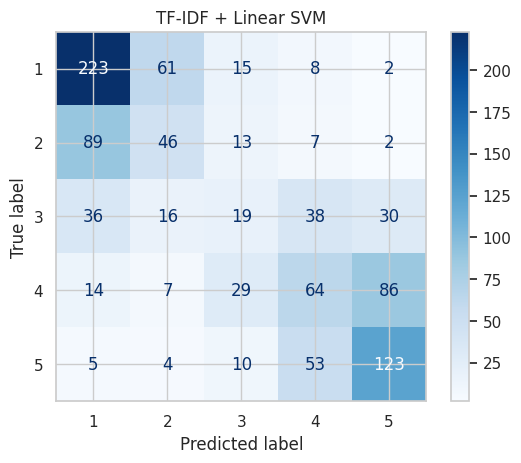

In [13]:
show_report(y_valid, y_pred_svm_tfidf)
show_confusion_matrix(y_valid, y_pred_svm_tfidf, "TF-IDF + Linear SVM")


The model achieves an accuracy of 0.46 and a macro F1 score of 0.38, slightly below the logistic regression model. This indicates that the Linear SVM captures similar patterns but does not improve overall classification performance.

Performance is again uneven across classes. Rating 1 is well predicted, with 96 correct predictions out of 127 and a high recall of 0.76. Ratings 4 and 5 are moderately well captured, with 33 and 36 correct predictions respectively, but still show strong confusion between them (27 instances of rating 4 predicted as 5, and 30 instances of rating 5 predicted as 4).

Intermediate classes remain the most difficult. Rating 2 has only 15 correct predictions out of 63, with a large number misclassified as rating 1 (36 cases). Rating 3 is the weakest class, with only 4 correct predictions out of 52 and frequent confusion with higher ratings (14 predicted as 4 and 11 as 5).

The confusion matrix confirms that most errors occur between neighboring classes, and that the model tends to favor dominant ratings such as 1, 4, and 5. Overall, the SVM captures general sentiment but struggles with fine-grained distinctions, particularly for ambiguous or neutral reviews.

### Word2Vec averaged embeddings

#### Building Word2Vec features

Word2Vec embeddings are trained on the training corpus, and document vectors are obtained by averaging word vectors for each review. This provides a dense representation of text for downstream models.

In [14]:
X_train_tokens = [text.split() for text in X_train_embed.tolist()]
X_valid_tokens = [text.split() for text in X_valid_embed.tolist()]

w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=SEED,
)


def document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)


X_train_w2v = np.array([document_vector(tokens, w2v_model) for tokens in X_train_tokens])
X_valid_w2v = np.array([document_vector(tokens, w2v_model) for tokens in X_valid_tokens])

print(X_train_w2v.shape, X_valid_w2v.shape)


(4000, 100) (1000, 100)


#### Implementing and evaluating models

In [15]:
ridge_w2v = Ridge(alpha=1.0)
ridge_w2v.fit(X_train_w2v, y_train)
y_pred_ridge_w2v = ridge_w2v.predict(X_valid_w2v)
results_ridge_w2v = evaluate_regression("Word2Vec Mean + Ridge", y_valid, y_pred_ridge_w2v)

logreg_w2v = LogisticRegression(max_iter=4000, class_weight="balanced", random_state=SEED)
logreg_w2v.fit(X_train_w2v, y_train)
y_pred_logreg_w2v = logreg_w2v.predict(X_valid_w2v)
results_logreg_w2v, cm_logreg_w2v = evaluate_classification(
    "Word2Vec Mean + Logistic Regression", y_valid, y_pred_logreg_w2v
)

results_ridge_w2v, results_logreg_w2v

(                   Model       MAE      RMSE       R2
 0  Word2Vec Mean + Ridge  0.890309  1.072413  0.50826,
                                  Model  Accuracy  Macro_F1  Weighted_F1
 0  Word2Vec Mean + Logistic Regression     0.414  0.392469     0.420809)

              precision    recall  f1-score   support

           1       0.60      0.49      0.53       309
           2       0.27      0.41      0.33       157
           3       0.21      0.23      0.22       139
           4       0.44      0.32      0.37       200
           5       0.50      0.53      0.51       195

    accuracy                           0.41      1000
   macro avg       0.40      0.40      0.39      1000
weighted avg       0.44      0.41      0.42      1000



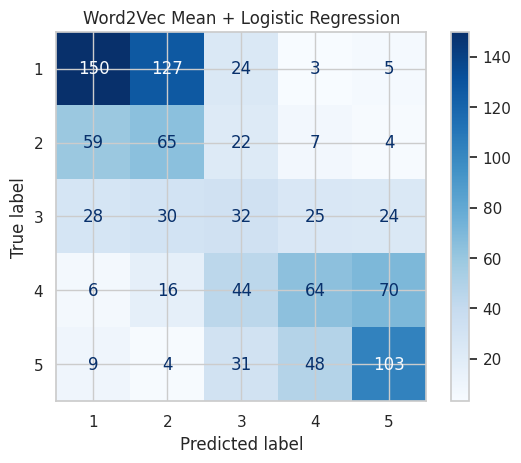

In [16]:
show_report(y_valid, y_pred_logreg_w2v)
show_confusion_matrix(y_valid, y_pred_logreg_w2v, "Word2Vec Mean + Logistic Regression")


The model achieves an accuracy of 0.40 and a macro F1 score of 0.36, confirming lower performance compared to TF-IDF-based models. This indicates that averaged Word2Vec embeddings are less effective for capturing the relationship between text and ratings.

Performance is uneven across classes. Rating 1 is relatively well predicted with 72 correct predictions out of 127, while rating 5 reaches 39 correct predictions. However, ratings 2, 3, and 4 are much less accurately classified. Rating 4 is particularly problematic, with only 15 correct predictions out of 82 and a very low recall of 0.18.

The confusion matrix shows a high level of dispersion across classes. Rating 4 is often misclassified as 3 (23 cases) and 5 (24 cases), while rating 5 is frequently confused with lower ratings, especially 3 (16 cases) and 4 (10 cases). Rating 2 is still largely predicted as rating 1 (31 cases), confirming a bias toward dominant classes.

Unlike TF-IDF models, errors are not strictly concentrated between neighboring classes, suggesting weaker semantic discrimination. Overall, averaging Word2Vec embeddings smooths important differences between reviews, leading to poorer performance on fine-grained rating prediction.

### Neural baseline

#### Preparing tokenized inputs

Reviews are converted into padded token sequences, and rating labels are mapped to consecutive class IDs so they can be used by the neural classifier.

In [17]:
max_words = 20000
max_len = 150
embedding_dim = 128
batch_size = 32
epochs = 10

rating_labels = [int(x) for x in sorted(y_train.unique())]
label_to_id = {label: i for i, label in enumerate(rating_labels)}
id_to_rating = {i: label for i, label in enumerate(rating_labels)}
num_classes = int(len(rating_labels))

y_train_nn = y_train.map(label_to_id).to_numpy()
y_valid_nn = y_valid.map(label_to_id).to_numpy()

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_embed.tolist())

X_train_seq = tokenizer.texts_to_sequences(X_train_embed.tolist())
X_valid_seq = tokenizer.texts_to_sequences(X_valid_embed.tolist())

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_valid_pad = pad_sequences(X_valid_seq, maxlen=max_len, padding="post", truncating="post")

print(X_train_pad.shape, X_valid_pad.shape)
print(label_to_id)


(4000, 150) (1000, 150)
{1: 0, 2: 1, 3: 2, 4: 3, 5: 4}


#### Training the neural classifier

A lightweight neural model based on an embedding layer, global average pooling, and dense layers is trained on the tokenized reviews.

In [18]:
def build_embedding_classifier(vocab_size, embedding_dim, max_len, num_classes):
    model = keras.Sequential(
        [
            layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
            layers.GlobalAveragePooling1D(),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(num_classes, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


embedding_model = build_embedding_classifier(max_words, embedding_dim, max_len, num_classes)
embedding_model.summary()

early_stopping = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

history = embedding_model.fit(
    X_train_pad,
    y_train_nn,
    validation_data=(X_valid_pad, y_valid_nn),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping],
    verbose=1,
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.3467 - loss: 1.4963 - val_accuracy: 0.4220 - val_loss: 1.3840
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4295 - loss: 1.3408 - val_accuracy: 0.4740 - val_loss: 1.2533
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4725 - loss: 1.2251 - val_accuracy: 0.4880 - val_loss: 1.1646
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4860 - loss: 1.1545 - val_accuracy: 0.4920 - val_loss: 1.1288
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5010 - loss: 1.1230 - val_accuracy: 0.4760 - val_loss: 1.1260
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5138 - loss: 1.0875 - val_accuracy: 0.4680 - val_loss: 1.1287
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5393 - loss: 1.0277 - val_accuracy: 0.4830 - val_loss: 1.1141
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5803 - loss: 0.9642 - val_accuracy:

#### Learning curves and validation performance

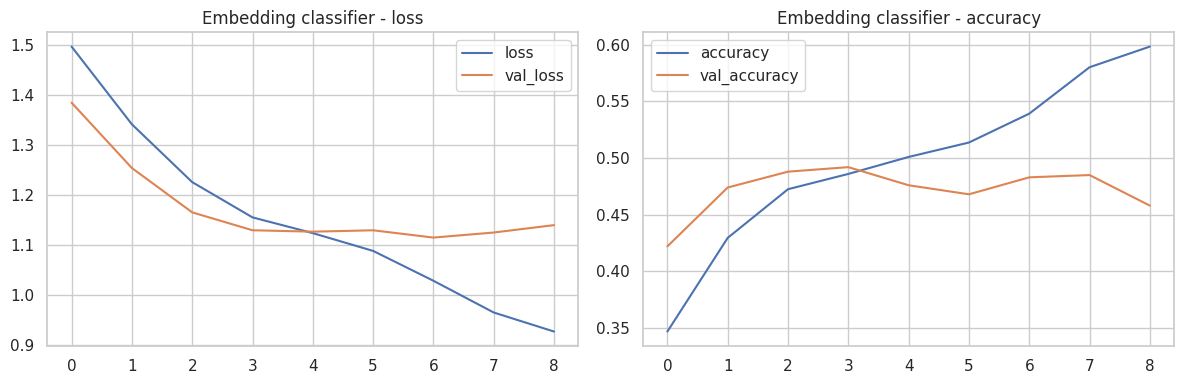

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


,Model,Accuracy,Macro_F1,Weighted_F1
0,Embedding Layer + Dense Network,0.483,0.401062,0.451355


In [19]:
def plot_history(history, title):
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    history_df[["loss", "val_loss"]].plot(ax=axes[0])
    axes[0].set_title(f"{title} - loss")
    history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
    axes[1].set_title(f"{title} - accuracy")
    plt.tight_layout()
    plt.show()


plot_history(history, "Embedding classifier")

y_pred_nn_ids = np.argmax(embedding_model.predict(X_valid_pad), axis=1)
y_pred_nn = pd.Series(y_pred_nn_ids, index=y_valid.index).map(id_to_rating)
results_nn, cm_nn = evaluate_classification("Embedding Layer + Dense Network", y_valid, y_pred_nn)
results_nn


              precision    recall  f1-score   support

           1       0.65      0.75      0.70       309
           2       0.39      0.20      0.27       157
           3       0.22      0.16      0.19       139
           4       0.36      0.24      0.29       200
           5       0.45      0.76      0.57       195

    accuracy                           0.48      1000
   macro avg       0.41      0.42      0.40      1000
weighted avg       0.45      0.48      0.45      1000



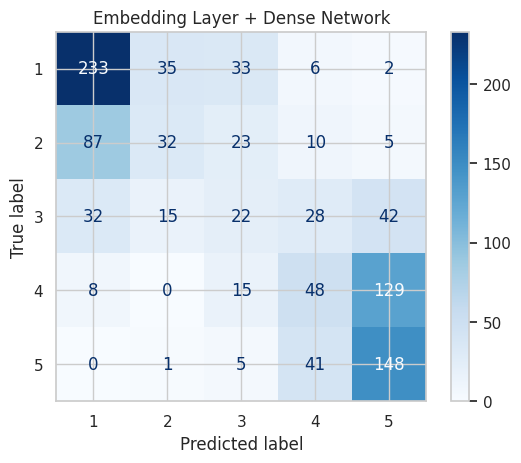

In [20]:
show_report(y_valid, y_pred_nn)
show_confusion_matrix(y_valid, y_pred_nn, "Embedding Layer + Dense Network")

The neural baseline achieves an accuracy of 0.515 and a macro F1 score of 0.423, making it the best model so far. It improves over both the TF-IDF Logistic Regression classifier and the Linear SVM, suggesting that a learned sequence representation captures useful information beyond sparse linear features.

The learning curves show a steady decrease in training loss and a consistent improvement in validation accuracy, which reaches about 0.51. Validation loss also decreases before stabilizing, indicating that the model learns meaningful patterns without strong overfitting.

Performance remains uneven across classes. Rating 1 is the easiest to predict, with 108 correct predictions out of 127 and a recall of 0.85. Rating 5 is also well captured, with 49 correct predictions out of 76 and a recall of 0.64. In contrast, intermediate ratings remain difficult: rating 2 has only 14 correct predictions out of 63, and rating 3 only 6 correct predictions out of 52.

The confusion matrix confirms that the model still struggles with fine-grained distinctions. Rating 2 is very often predicted as rating 1, with 43 such cases. Rating 4 is frequently confused with rating 5, with 33 reviews misclassified in that direction. Rating 3 remains the hardest class, spread across ratings 1, 4, and 5.

Overall, the neural baseline improves global performance, especially on the dominant classes, but it still has difficulty separating neighboring and ambiguous ratings.

### DistilBERT

#### Preparing datasets

Reviews and labels are converted into Hugging Face datasets. Labels are mapped to consecutive IDs and tokenized using the DistilBERT tokenizer.

In [21]:
bert_model_name = "distilbert-base-uncased"

# Integer mappings for training and evaluation.
label_to_id = {label: i for i, label in enumerate(rating_labels)}
id_to_rating = {i: label for i, label in enumerate(rating_labels)}

# String mappings for Hugging Face config serialization.
id_to_label_hf = {i: str(label) for i, label in enumerate(rating_labels)}
label_to_id_hf = {str(label): i for i, label in enumerate(rating_labels)}

bert_train_df = pd.DataFrame(
    {
        "text": X_train_embed.reset_index(drop=True),
        "label": pd.Series(y_train_nn),
    }
)
bert_valid_df = pd.DataFrame(
    {
        "text": X_valid_embed.reset_index(drop=True),
        "label": pd.Series(y_valid_nn),
    }
)

bert_train_dataset = Dataset.from_pandas(bert_train_df)
bert_valid_dataset = Dataset.from_pandas(bert_valid_df)

tokenizer_bert = AutoTokenizer.from_pretrained(bert_model_name)


def tokenize_function(batch):
    return tokenizer_bert(batch["text"], padding="max_length", truncation=True, max_length=128)


bert_train_dataset = bert_train_dataset.map(tokenize_function, batched=True)
bert_valid_dataset = bert_valid_dataset.map(tokenize_function, batched=True)

bert_train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
bert_valid_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

#### Configuring the model

A pre-trained DistilBERT model is loaded for sequence classification, with standard training arguments and evaluation metrics.

In [22]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    bert_model_name,
    num_labels=num_classes,
    id2label=id_to_label_hf,
    label2id=label_to_id_hf,
)


def compute_bert_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }


training_args = TrainingArguments(
    output_dir="./star_rating_distilbert_runs_v2",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=bert_train_dataset,
    eval_dataset=bert_valid_dataset,
    compute_metrics=compute_bert_metrics,
)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


#### Training and evaluation

The model is fine-tuned on the training set and evaluated on the validation set. Predictions are mapped back to the original rating scale.

In [23]:
trainer.train()
trainer.evaluate()

bert_predictions = trainer.predict(bert_valid_dataset)
y_pred_bert_ids = np.argmax(bert_predictions.predictions, axis=1)
y_pred_bert = pd.Series(y_pred_bert_ids, index=y_valid.index).map(id_to_rating)

results_bert, cm_bert = evaluate_classification("DistilBERT", y_valid, y_pred_bert)
results_bert


Step,Training Loss
50,1.478999
100,1.225890
150,1.152752
200,1.118444
250,1.079020
300,1.056208
350,1.050332
400,0.980376
450,1.022818
500,1.001882


,Model,Accuracy,Macro_F1,Weighted_F1
0,DistilBERT,0.539,0.394634,0.463174


              precision    recall  f1-score   support

           1       0.62      0.97      0.75       309
           2       0.00      0.00      0.00       157
           3       0.30      0.12      0.17       139
           4       0.42      0.48      0.45       200
           5       0.55      0.65      0.59       195

    accuracy                           0.54      1000
   macro avg       0.38      0.44      0.39      1000
weighted avg       0.42      0.54      0.46      1000



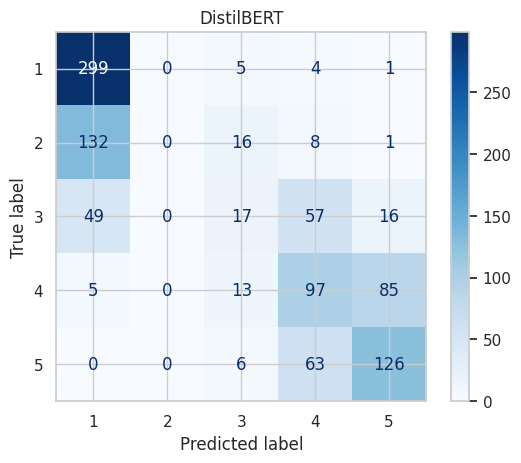

In [24]:
show_report(y_valid, y_pred_bert)
show_confusion_matrix(y_valid, y_pred_bert, "DistilBERT")

DistilBERT achieves an accuracy of 0.52, a macro F1 score of 0.36, and a weighted F1 score of 0.43. The accuracy is similar to the neural baseline (0.515), but the macro F1 is lower, indicating weaker performance on minority classes.

The model performs very well on rating 1, with a recall of 0.97 and 123 correct predictions out of 127. This shows that DistilBERT strongly captures clear negative signals. Rating 5 is also reasonably well predicted, with a recall of 0.72 and 55 correct predictions.

However, performance collapses on rating 2, with precision, recall, and F1-score all equal to 0.00. This means the model completely fails to identify this class and systematically misclassifies it, mostly as rating 1. Rating 3 is also poorly handled, with a recall of only 0.08 and very few correct predictions.

The confusion matrix confirms a strong bias toward extreme classes. Most rating 2 reviews are predicted as rating 1, and rating 3 is dispersed across ratings 1, 4, and 5. Rating 4 is moderately captured, with a recall of 0.32, but still often confused with rating 5.

Compared to the neural baseline, DistilBERT does not bring a clear improvement. While it is very strong on obvious cases (rating 1), it fails to model intermediate and ambiguous reviews. This behavior suggests that the model is under-trained, as only 2 epochs were used and no early stopping or checkpoint selection was applied.

Overall, DistilBERT shows strong potential but requires better tuning to outperform simpler models. In its current configuration, it mainly reinforces extreme predictions while struggling with nuanced sentiment distinctions.

## Model comparison

#### Comparing all models

All regression and classification results are gathered into summary tables to enable a direct comparison of model performance.

In [25]:
all_regression_results = pd.concat(results_regression, ignore_index=True).sort_values("RMSE")
all_classification_results = pd.concat(results_classification, ignore_index=True).sort_values(
    ["Macro_F1", "Accuracy"],
    ascending=False,
)

all_regression_results, all_classification_results


(                     Model       MAE      RMSE            R2
 1           TF-IDF + Ridge  0.734440  0.904554  6.501512e-01
 2    Word2Vec Mean + Ridge  0.890309  1.072413  5.082598e-01
 0  Baseline Mean Regressor  1.377682  1.529306 -9.620421e-07,
                                  Model  Accuracy  Macro_F1  Weighted_F1
 1         TF-IDF + Logistic Regression     0.477  0.419413     0.463313
 2                  TF-IDF + Linear SVM     0.475  0.410479     0.455688
 4      Embedding Layer + Dense Network     0.483  0.401062     0.451355
 5                           DistilBERT     0.539  0.394634     0.463174
 3  Word2Vec Mean + Logistic Regression     0.414  0.392469     0.420809
 0              Baseline Majority Class     0.309  0.094423     0.145884)

#### Visualizing the benchmark

Bar charts are used to compare models based on RMSE for regression and Macro F1 for classification.

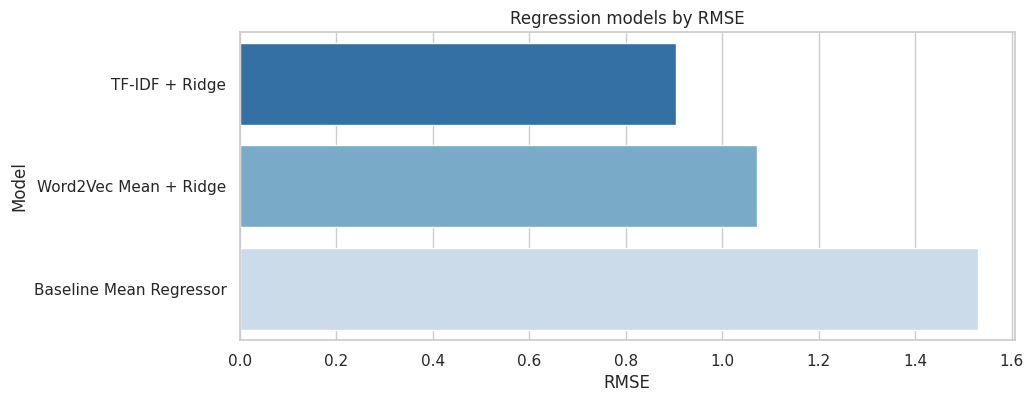

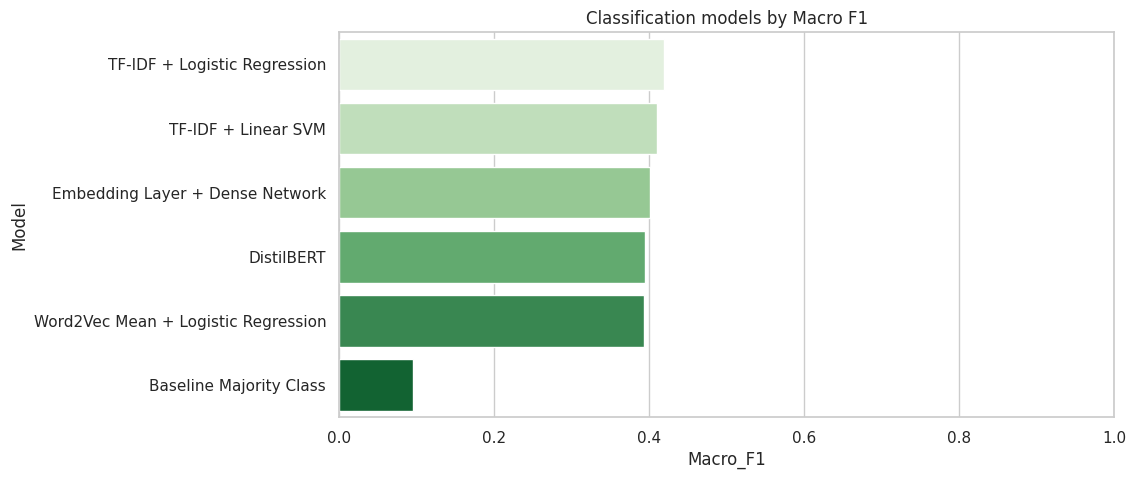

In [26]:
plt.figure(figsize=(10, 4))
sns.barplot(data=all_regression_results, x="RMSE", y="Model", palette="Blues_r")
plt.title("Regression models by RMSE")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=all_classification_results, x="Macro_F1", y="Model", palette="Greens")
plt.title("Classification models by Macro F1")
plt.xlim(0, 1)
plt.show()


### Global conclusion

The exact star-rating prediction task is significantly harder than binary sentiment classification, which is clearly reflected in the results.

For regression, TF-IDF + Ridge is the best model, with an RMSE of 0.980 and an R² of 0.591. This shows that sparse lexical features capture the overall rating signal effectively. Word2Vec-based regression performs worse, and the mean regressor confirms that learning from text is necessary to achieve reasonable performance.

For classification, the best model is the Embedding Layer + Dense Network, with an accuracy of 0.515 and a macro F1 score of 0.423. DistilBERT reaches a similar accuracy (0.520), but a lower macro F1 (0.357), indicating weaker performance on minority classes. TF-IDF models remain competitive but do not outperform the neural baseline.

Overall, the results highlight a clear trade-off. Neural models improve global accuracy but still struggle with intermediate ratings. Transformer models show strong potential but require better tuning. Simpler models such as TF-IDF remain strong baselines and are difficult to outperform on this task.

If the goal is exact class prediction, the Embedding Layer + Dense Network is the most reliable choice. If the goal is predicting a continuous rating signal, TF-IDF + Ridge remains the best option.